# BDI Layer - ML Classifier Training and Testing
## Train on DZ, Overtaking, Intersection datasets | Test on Fusion Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Load and Prepare Data

In [2]:
# Load datasets
print("Loading training datasets...")
df_dz = pd.read_csv('../dataset_apres_smote_DZ.csv')
df_overtaking = pd.read_csv('../dataset_apres_smote_overtaking.csv')
df_intersection = pd.read_csv('../intersection.csv')
df_fusion = pd.read_csv('../Fusion_dataset.csv')

print(f"DZ shape: {df_dz.shape}, Overtaking shape: {df_overtaking.shape}")
print(f"Intersection shape: {df_intersection.shape}, Fusion shape: {df_fusion.shape}")

# Add labels
df_dz['scenario'] = 'danger_zone'
df_overtaking['scenario'] = 'overtaking'
df_intersection['scenario'] = 'intersection'

# Combine
df_train = pd.concat([df_dz, df_overtaking, df_intersection], ignore_index=True)
print(f"\nCombined training set: {df_train.shape}")
print(f"Scenarios: {df_train['scenario'].value_counts().to_dict()}")

Loading training datasets...
DZ shape: (25689, 19), Overtaking shape: (33778, 17)
Intersection shape: (57471, 12), Fusion shape: (103643, 26)

Combined training set: (116938, 25)
Scenarios: {'intersection': 57471, 'overtaking': 33778, 'danger_zone': 25689}


In [3]:
# Select features
exclude_cols = ['Time', 'VehicleId', 'scenario', 'Pos_x', 'Pos_y']
feature_cols = [col for col in df_train.columns 
                 if col not in exclude_cols and col in df_train.columns
                 and df_train[col].dtype in ['int64', 'float64']]

print(f"Selected {len(feature_cols)} features")

# Handle missing values
df_train = df_train.fillna(df_train.mean(numeric_only=True))

X_train = df_train[feature_cols].copy()
y_train = df_train['scenario'].copy()

# Convert boolean columns
for col in X_train.columns:
    if X_train[col].dtype == 'bool':
        X_train[col] = X_train[col].astype(int)

print(f"Features shape: {X_train.shape}, Target shape: {y_train.shape}")

Selected 14 features
Features shape: (116938, 14), Target shape: (116938,)


In [4]:
# Split and scale
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}")
print(f"Training distribution: {y_train_split.value_counts().to_dict()}")

Train: (93550, 14), Val: (23388, 14)
Training distribution: {'intersection': 45977, 'overtaking': 27022, 'danger_zone': 20551}


## Train and Evaluate Model

In [5]:
# Train model
print("Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train_split)
print(f"Model trained! Training accuracy: {model.score(X_train_scaled, y_train_split):.4f}")

Training Random Forest Classifier...
Model trained! Training accuracy: 1.0000


In [6]:
# Validation evaluation
y_val_pred = model.predict(X_val_scaled)

print("\n=== VALIDATION RESULTS ===")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_val_pred, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

cm_val = confusion_matrix(y_val, y_val_pred)
print(f"\nConfusion Matrix:\n{cm_val}")


=== VALIDATION RESULTS ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Classification Report:
              precision    recall  f1-score   support

 danger_zone       1.00      1.00      1.00      5138
intersection       1.00      1.00      1.00     11494
  overtaking       1.00      1.00      1.00      6756

    accuracy                           1.00     23388
   macro avg       1.00      1.00      1.00     23388
weighted avg       1.00      1.00      1.00     23388


Confusion Matrix:
[[ 5138     0     0]
 [    0 11494     0]
 [    0     0  6756]]


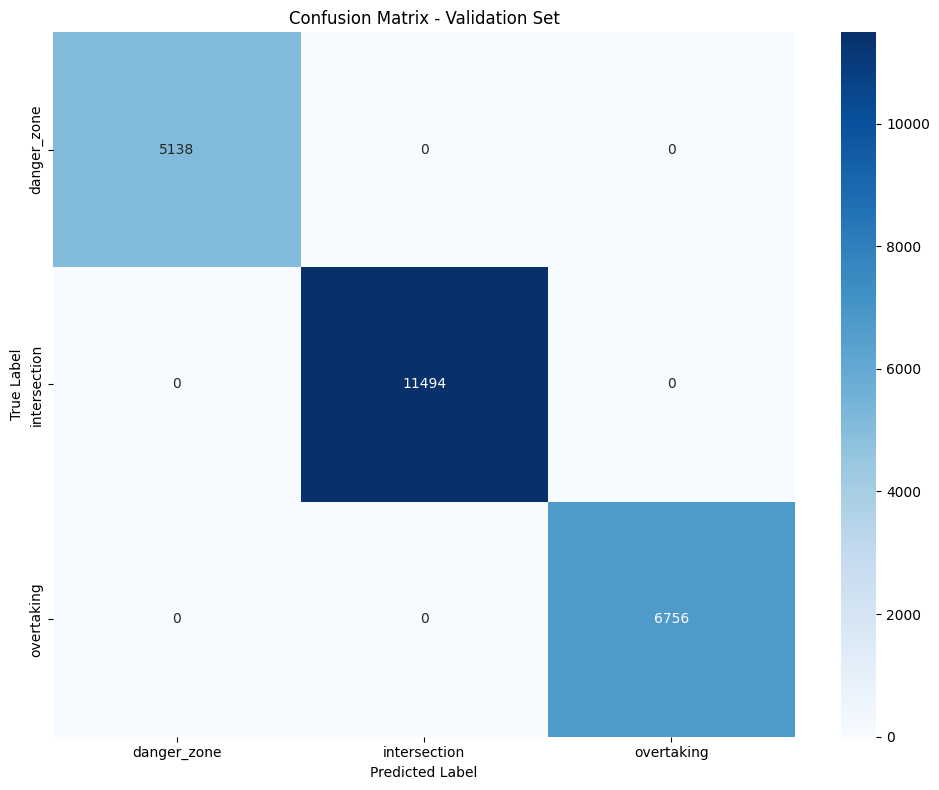

✓ Validation confusion matrix plotted


In [7]:
# Visualize validation confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
print("✓ Validation confusion matrix plotted")

## Test on Fusion Dataset

In [8]:
# Prepare Fusion dataset
print("Preparing Fusion dataset...")
df_fusion_clean = df_fusion.fillna(df_fusion.mean(numeric_only=True))

# Add missing features with mean values from training
for col in feature_cols:
    if col not in df_fusion_clean.columns:
        mean_val = X_train[col].mean()
        df_fusion_clean[col] = mean_val
        print(f"Added missing column '{col}' with mean: {mean_val:.2f}")

X_fusion = df_fusion_clean[feature_cols].copy()

# Convert boolean columns
for col in X_fusion.columns:
    if X_fusion[col].dtype == 'bool':
        X_fusion[col] = X_fusion[col].fillna(False).astype(int)

X_fusion_scaled = scaler.transform(X_fusion)
print(f"✓ Fusion dataset prepared: {X_fusion_scaled.shape}")

Preparing Fusion dataset...
Added missing column 'Slope' with mean: 0.00
✓ Fusion dataset prepared: (103643, 14)


In [9]:
# Test on Fusion dataset
y_fusion_pred = model.predict(X_fusion_scaled)

print("\n=== FUSION DATASET TEST RESULTS ===")
print(f"Predictions distribution:")
unique, counts = np.unique(y_fusion_pred, return_counts=True)
for scenario, count in zip(unique, counts):
    print(f"  {scenario}: {count:,} samples ({100*count/len(y_fusion_pred):.1f}%)")

# Check if Fusion has target column
if 'Scenario' in df_fusion.columns:
    print("\n✓ Scenario column found in Fusion dataset")
    # Map scenario names if needed
    y_fusion_true = df_fusion['Scenario'].fillna('unknown')
    
    # Only calculate metrics for matching scenarios
    valid_mask = y_fusion_true.isin(model.classes_)
    if valid_mask.sum() > 0:
        y_fusion_true_filtered = y_fusion_true[valid_mask]
        y_fusion_pred_filtered = y_fusion_pred[valid_mask]
        
        print(f"\nAccuracy:  {accuracy_score(y_fusion_true_filtered, y_fusion_pred_filtered):.4f}")
        print(f"Precision: {precision_score(y_fusion_true_filtered, y_fusion_pred_filtered, average='weighted', zero_division=0):.4f}")
        print(f"Recall:    {recall_score(y_fusion_true_filtered, y_fusion_pred_filtered, average='weighted', zero_division=0):.4f}")
        print(f"F1-Score:  {f1_score(y_fusion_true_filtered, y_fusion_pred_filtered, average='weighted', zero_division=0):.4f}")
        
        cm_fusion = confusion_matrix(y_fusion_true_filtered, y_fusion_pred_filtered, labels=model.classes_)
        print(f"\nConfusion Matrix:\n{cm_fusion}")
else:
    print("\n⚠ No Scenario column found in Fusion dataset - predictions only")


=== FUSION DATASET TEST RESULTS ===
Predictions distribution:
  danger_zone: 25,689 samples (24.8%)
  intersection: 44,176 samples (42.6%)
  overtaking: 33,778 samples (32.6%)

✓ Scenario column found in Fusion dataset

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Confusion Matrix:
[[25689     0     0]
 [    0 44176     0]
 [    0     0 33778]]


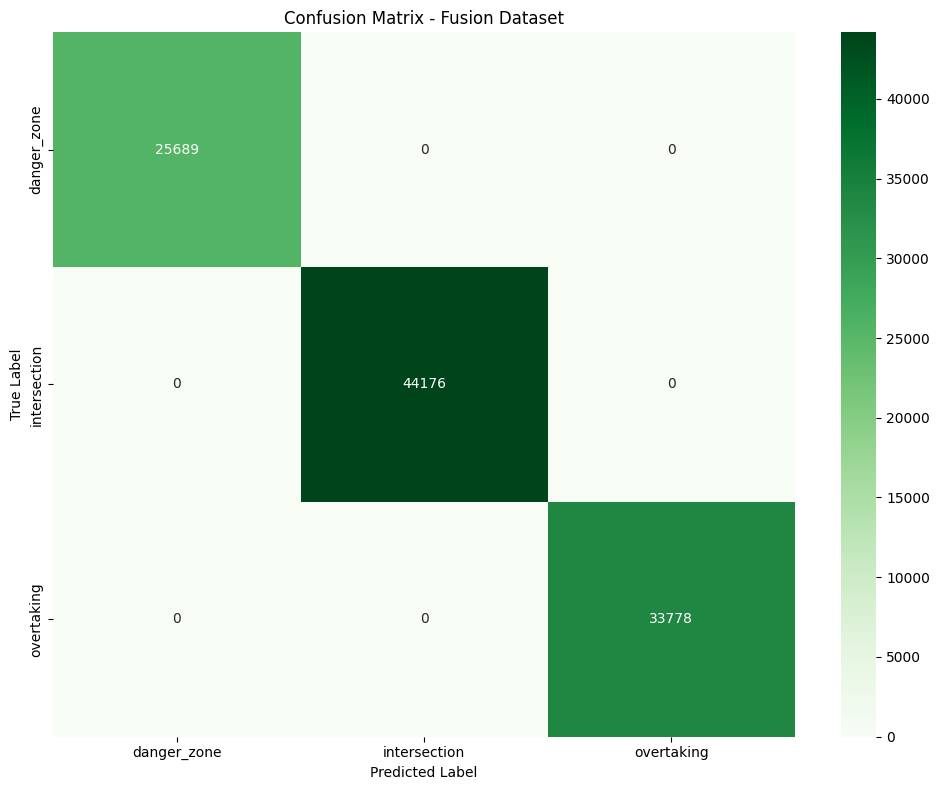

✓ Fusion confusion matrix plotted


In [10]:
# Visualize Fusion confusion matrix if available
if 'Scenario' in df_fusion.columns:
    y_fusion_true = df_fusion['Scenario'].fillna('unknown')
    valid_mask = y_fusion_true.isin(model.classes_)
    
    if valid_mask.sum() > 0:
        y_fusion_true_filtered = y_fusion_true[valid_mask]
        y_fusion_pred_filtered = y_fusion_pred[valid_mask]
        cm_fusion = confusion_matrix(y_fusion_true_filtered, y_fusion_pred_filtered, labels=model.classes_)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Greens',
                    xticklabels=model.classes_, yticklabels=model.classes_)
        plt.title('Confusion Matrix - Fusion Dataset')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()
        print("✓ Fusion confusion matrix plotted")
else:
    print("Skipping visualization - no target labels available")

## Feature Importance & Summary


Top 10 Most Important Features:
             Feature  Importance
                Lane    0.223505
        SafeDistance    0.138532
SafeUnsafeOvertaking    0.115980
            LanePrev    0.114155
       RelativeSpeed    0.110046
      SafeDangerZone    0.095243
        Deceleration    0.075724
           LeaderGap    0.037547
         LeaderSpeed    0.029029
                 TTC    0.025555


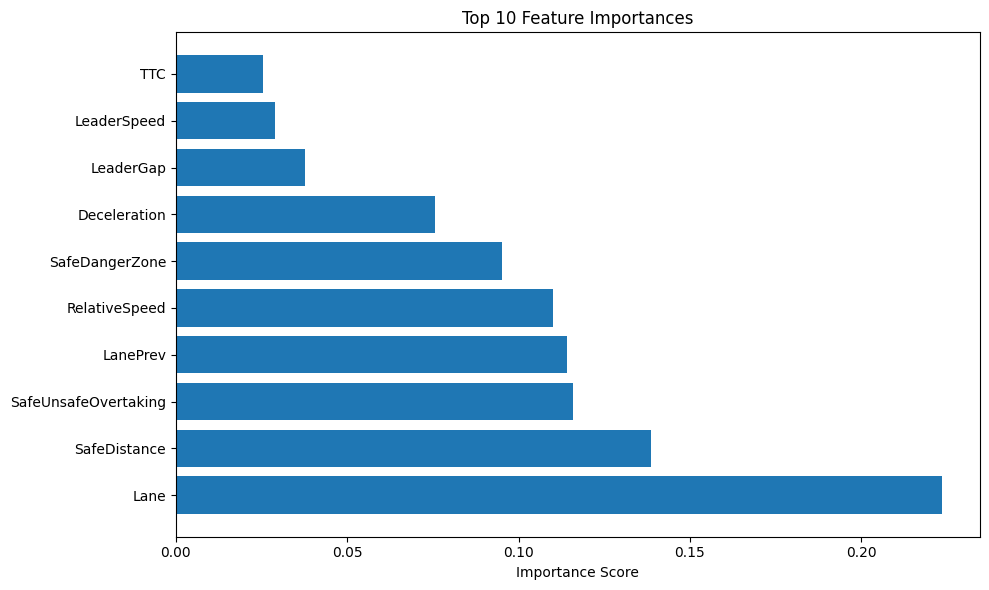

In [11]:
# Feature importance
if hasattr(model, 'feature_importances_'):
    feature_imp = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(feature_imp.head(10).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    top10 = feature_imp.head(10)
    plt.barh(range(len(top10)), top10['Importance'])
    plt.yticks(range(len(top10)), top10['Feature'])
    plt.xlabel('Importance Score')
    plt.title('Top 10 Feature Importances')
    plt.tight_layout()
    plt.show()

In [12]:
# Save model
joblib.dump(model, '../bdi_classifier_model.joblib')
joblib.dump(scaler, '../bdi_classifier_scaler.joblib')
joblib.dump(feature_cols, '../bdi_classifier_features.joblib')

print("\n" + "="*70)
print("✓ MODEL TRAINING COMPLETE")
print("="*70)
print(f"Model saved: ../bdi_classifier_model.joblib")
print(f"Scaler saved: ../bdi_classifier_scaler.joblib")
print(f"Features saved: ../bdi_classifier_features.joblib")
print(f"\nModel: Random Forest")
print(f"Training samples: {len(X_train_split):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Fusion test samples: {len(X_fusion):,}")
print("="*70)


✓ MODEL TRAINING COMPLETE
Model saved: ../bdi_classifier_model.joblib
Scaler saved: ../bdi_classifier_scaler.joblib
Features saved: ../bdi_classifier_features.joblib

Model: Random Forest
Training samples: 93,550
Validation samples: 23,388
Fusion test samples: 103,643
